# Comprehensive 16S AnnData Analysis Workflow

This notebook provides a cohesive and comprehensive workflow for microbiome analysis using the `AnnData` format. It integrates data loading, quality control, filtering, diversity analysis, taxonomic composition, and results saving into a single, logical pipeline.

**Workflow Steps:**
1.  **Setup & Imports**: Load all necessary libraries and define paths.
2.  **Data Loading & Curation**: Find, validate, and concatenate multiple `.h5ad` files. Manually reconstruct the `.var` metadata.
3.  **Preprocessing & QC**: 
    - Parse detailed taxonomy (Kingdom, Phylum, etc.).
    - Filter empty samples, host-associated samples, and contaminants (chloroplast, mitochondria).
    - Calculate QC metrics and filter low-depth samples/features.
4.  **Phylogenetic Tree**: Export sequences to FASTA, provide instructions for external tree building (MAFFT, FastTree), and import the resulting tree.
5.  **Alpha Diversity (ASV Level)**: Calculate and visualize alpha diversity metrics.
6.  **Beta Diversity (ASV Level)**: Calculate and visualize PCoA plots for Bray-Curtis, Weighted UniFrac, and Unweighted UniFrac.
7.  **Taxonomic Composition**: Aggregate data to the Genus level and create a stacked bar plot of the top genera.
8.  **Save Results**: Store the fully processed ASV-level object (`adata`) and the Genus-level object (`adata_genus`) as `.h5ad` files.

## Part 1: Setup & Imports

In [1]:
# Install necessary libraries if not already installed
# !pip install scanpy anndata "leidenalg>=0.9" scikit-bio seaborn

import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
import re
from pathlib import Path

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For diversity analysis
import skbio
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa
from skbio.tree import TreeNode

# --- Set global parameters ---
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=False)
ad.settings.allow_write_nullable_strings = True

# --- IMPORTANT: Set your directory paths ---
DATA_DIR = Path("/usr2/people/macgregor/amplicon/project_01/03_processed_data/")
OUTPUT_DIR = Path("./anndata_pipeline_output") # A directory for our output files
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Define expected structure ---
EXPECTED_VAR_COLUMNS = {'Taxon', 'Confidence', 'sequence'}
EXPECTED_VAR_DTYPES = {
    'Taxon': 'string',
    'Confidence': 'Float64',
    'sequence': 'string'
}

print("Libraries imported and paths set successfully!")

Libraries imported and paths set successfully!


## Part 2: Data Loading & Curation

In [2]:
print("--- Step 2.1: Validating all files ---")
h5ad_files = list(DATA_DIR.glob("*.h5ad"))
if not h5ad_files:
    raise FileNotFoundError(f"No .h5ad files found in the directory: {DATA_DIR}")

print(f"Found {len(h5ad_files)} AnnData files to process.")

valid_adatas = {}
skipped_files = []

for f in h5ad_files:
    print(f"Checking: {f.name}")
    try:
        adata_individual = sc.read_h5ad(f)
    except Exception as e:
        print(f"  -> ❌ SKIPPING: Failed to read file. Error: {e}")
        skipped_files.append(f.name)
        continue

    should_skip = False
    skip_reason = ""

    if adata_individual.n_vars == 0:
        should_skip = True
        skip_reason = "File contains zero features."
    elif isinstance(adata_individual.var.index[0], int):
        should_skip = True
        skip_reason = "File has an incorrect integer-based index."
    elif not EXPECTED_VAR_COLUMNS.issubset(adata_individual.var.columns):
        missing = EXPECTED_VAR_COLUMNS - set(adata_individual.var.columns)
        should_skip = True
        skip_reason = f"File is missing required columns: {missing}"
    elif adata_individual.var[list(EXPECTED_VAR_COLUMNS)].isnull().all().any():
        empty_col = adata_individual.var[list(EXPECTED_VAR_COLUMNS)].isnull().all()
        empty_col = empty_col[empty_col].index[0]
        should_skip = True
        skip_reason = f"Required column '{empty_col}' contains no data."

    if should_skip:
        print(f"  -> ❌ SKIPPING: {skip_reason}")
        skipped_files.append(f.name)
        continue

    print(f"  -> ✅ OK: File is valid.")
    valid_adatas[f.stem] = adata_individual

--- Step 2.1: Validating all files ---
Found 40 AnnData files to process.
Checking: PRJDB10611.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
  -> ❌ SKIPPING: File is missing required columns: {'Confidence', 'sequence'}
Checking: PRJDB11204.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB11503.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB12584.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB12980.ILLUMINA.PAIRED.V4.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB3924.ILLUMINA.PAIRED.V4.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB11204.ILLUMINA.PAIRED.V4.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB5190.ILLUMINA.PAIRED.V4.FWD_N_A.REV_N_A.h5ad
  -> ❌ SKIPPING: Required column 'Confidence' contains no data.
Checking: PRJDB6739.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
  -> ✅ OK: File is valid.
Checking: PRJDB7915.ILLUMINA.PAIRED.V4.FW

In [3]:
if not valid_adatas:
    print("No valid AnnData objects were found to concatenate. Exiting.")
else:
    print("\n--- Step 2.2: Concatenating valid objects ---")
    adata = ad.concat(
        valid_adatas,
        join='outer',
        label='batch',
        fill_value=0
    )

    print("\n--- Step 2.3: Manually reconstructing .var metadata ---")
    all_vars = [ad_obj.var[list(EXPECTED_VAR_COLUMNS)] for ad_obj in valid_adatas.values()]
    combined_var = pd.concat(all_vars)
    
    # Remove duplicate features, keeping the first metadata entry found
    combined_var_unique = combined_var[~combined_var.index.duplicated(keep='first')]
    
    # Reindex this correct metadata to match the final AnnData object's feature index
    final_var = combined_var_unique.reindex(adata.var_names)
    final_var = final_var.astype(EXPECTED_VAR_DTYPES)
    
    # Replace the empty .var with our manually created one
    adata.var = final_var
    
    # --- Finalization ---
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adata.obs_names.name = 'sample_id'
    adata.var_names.name = 'feature_id'

    print("\n✅ AnnData objects concatenated and fixed successfully.")

    if skipped_files:
        unique_skipped = sorted(list(set(skipped_files)))
        print("\nThe following files were SKIPPED:")
        for fname in unique_skipped:
            print(f"- {fname}")

    print("\nCombined AnnData object shape:")
    print(f"    Observations (samples): {adata.n_obs}")
    print(f"    Variables (features): {adata.n_vars}")

    print("\nFinal .var dataframe head:")
    print(adata.var.head())


--- Step 2.2: Concatenating valid objects ---


/usr2/people/macgregor/miniconda3/envs/workflow_16s/lib/python3.10/site-packages/anndata/_core/merge.py:1356: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col



--- Step 2.3: Manually reconstructing .var metadata ---

✅ AnnData objects concatenated and fixed successfully.

The following files were SKIPPED:
- PRJDB10611.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
- PRJDB5190.ILLUMINA.PAIRED.V4.FWD_N_A.REV_N_A.h5ad
- PRJDB9040.ILLUMINA.SINGLE.V4-V5.FWD_N_A.REV_N_A.h5ad
- PRJEB12499.ILLUMINA.PAIRED.V2-V3.FWD_N_A.REV_N_A.h5ad
- PRJEB12502.LS454.SINGLE.V1.FWD_N_A.REV_N_A.h5ad

Combined AnnData object shape:
    Observations (samples): 1255
    Variables (features): 160489

Final .var dataframe head:
                                  Confidence  \
feature_id                                     
000009439ee8b7838b54f6e03d954ad2    0.999948   
00004f4bfac2a0c979c053a0e82c2035    0.999948   
0000b5d607cea060f34423805a5e2334    0.958317   
0000c3abc78e6c722d1f01c7f45bf50a    0.971739   
000126213e389eaf6295a0fe866354e6    0.998929   

                                                                              Taxon  \
feature_id                       

## Part 3: Preprocessing & QC

In [4]:
print("--- Step 3.1: Parsing Taxonomy ---")
if 'Taxon' in adata.var.columns:
    tax_levels = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    
    # Split the 'Taxon' column
    parsed_taxonomy = adata.var['Taxon'].str.split(';', expand=True)
    parsed_taxonomy.columns = tax_levels[:parsed_taxonomy.shape[1]]
    
    # Clean the prefixes (like 'd__') from each new column
    for col in parsed_taxonomy.columns:
        parsed_taxonomy[col] = parsed_taxonomy[col].str.replace(r'.*?([dpcofgs])__', '', regex=True)
    
    # Replace empty strings or 'Unassigned' with NaN
    parsed_taxonomy.replace(['', 'Unassigned', 'unassigned'], np.nan, inplace=True)
    
    # Concatenate the new columns back into adata.var
    adata.var = pd.concat([adata.var, parsed_taxonomy], axis=1)
    print("Successfully added parsed taxonomic columns.")
    display(adata.var.head())
else:
    print("Error: 'Taxon' column not found in adata.var!")

--- Step 3.1: Parsing Taxonomy ---
Successfully added parsed taxonomic columns.


,Confidence,Taxon,sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
feature_id,,,,,,,,,,
000009439ee8b7838b54f6e03d954ad2,0.999948,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,CCAGCCGCCGCGGTAATACGGAGGGGGCTAGCGTTGTTCGGAATTA...,Bacteria,Proteobacteria,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae,Sphingomonas,<NA>
00004f4bfac2a0c979c053a0e82c2035,0.999948,d__Bacteria; p__Acidobacteriota; c__Holophagae...,AGGGGGCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGCGCGTAG...,Bacteria,Acidobacteriota,Holophagae,Subgroup_7,Subgroup_7,Subgroup_7,<NA>
0000b5d607cea060f34423805a5e2334,0.958317,d__Bacteria; p__Verrucomicrobiota; c__Verrucom...,CCAGCAGCCGCGGTAATACAGAGGTCCCAAGCGTTGTTCGGATTCA...,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Pedosphaerales,Pedosphaeraceae,uncultured,bacterium_enrichment
0000c3abc78e6c722d1f01c7f45bf50a,0.971739,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,CCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTATCCGGATTCA...,Bacteria,Bacteroidota,Bacteroidia,Chitinophagales,Chitinophagaceae,Dinghuibacter,Dinghuibacter_silviterrae
000126213e389eaf6295a0fe866354e6,0.998929,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,TGTCAGCAGCCGCGGTAATACGAAGGGACCTAGCGTAGTTCGGAAT...,Bacteria,Proteobacteria,Alphaproteobacteria,SAR11_clade,Clade_III,Clade_III,Candidatus_Fonsibacter


In [5]:
print("\n--- Step 3.2: Filtering Empty and Host-Associated Samples ---")
print(f"Original sample count: {adata.n_obs}")

# Filter empty samples
empty_samples_mask = (adata.X.sum(axis=1) == 0)
if np.any(empty_samples_mask):
    print(f"Removing {np.sum(empty_samples_mask)} empty samples.")
    adata = adata[~empty_samples_mask, :].copy()

# Filter 'host-associated' samples
search_term = 'host-associated'
try:
    bool_df = adata.obs.applymap(lambda x: search_term in str(x).lower())
except AttributeError: # Fallback for newer pandas
    bool_df = adata.obs.astype(str).apply(lambda col: col.str.lower().str.contains(search_term, na=False))
    
samples_to_remove_mask = bool_df.any(axis=1)
print(f"Found and removing {samples_to_remove_mask.sum()} samples containing '{search_term}'.")
adata = adata[~samples_to_remove_mask, :].copy()

print(f"Sample count after filtering: {adata.n_obs}")


--- Step 3.2: Filtering Empty and Host-Associated Samples ---
Original sample count: 1255
Removing 14 empty samples.


/opt/tmp/ipykernel_2207264/4012602068.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  bool_df = adata.obs.applymap(lambda x: search_term in str(x).lower())


Found and removing 193 samples containing 'host-associated'.
Sample count after filtering: 1048


In [6]:
print("\n--- Step 3.3: Filtering Contaminant Features (Chloroplast & Mitochondria) ---")
print(f"Original feature count: {adata.n_vars}")

contaminant_terms = ['chloroplast', 'mitochondria']
contaminant_mask = pd.Series(False, index=adata.var_names)

for term in contaminant_terms:
    # Check all taxonomy columns for the term
    try:
        bool_df = adata.var.applymap(lambda x: term in str(x).lower())
    except AttributeError:
        bool_df = adata.var.astype(str).apply(lambda col: col.str.lower().str.contains(term, na=False))
    term_mask = bool_df.any(axis=1)
    print(f"Found {term_mask.sum()} ASVs matching '{term}'.")
    contaminant_mask = contaminant_mask | term_mask

print(f"Removing a total of {contaminant_mask.sum()} contaminant ASVs.")
adata = adata[:, ~contaminant_mask].copy()

print(f"Feature count after filtering: {adata.n_vars}")


--- Step 3.3: Filtering Contaminant Features (Chloroplast & Mitochondria) ---
Original feature count: 160489


/opt/tmp/ipykernel_2207264/3485198800.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  bool_df = adata.var.applymap(lambda x: term in str(x).lower())


Found 1954 ASVs matching 'chloroplast'.


/opt/tmp/ipykernel_2207264/3485198800.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  bool_df = adata.var.applymap(lambda x: term in str(x).lower())


Found 3023 ASVs matching 'mitochondria'.
Removing a total of 4977 contaminant ASVs.
Feature count after filtering: 155512



--- Step 3.4: Calculating and Visualizing QC Metrics ---


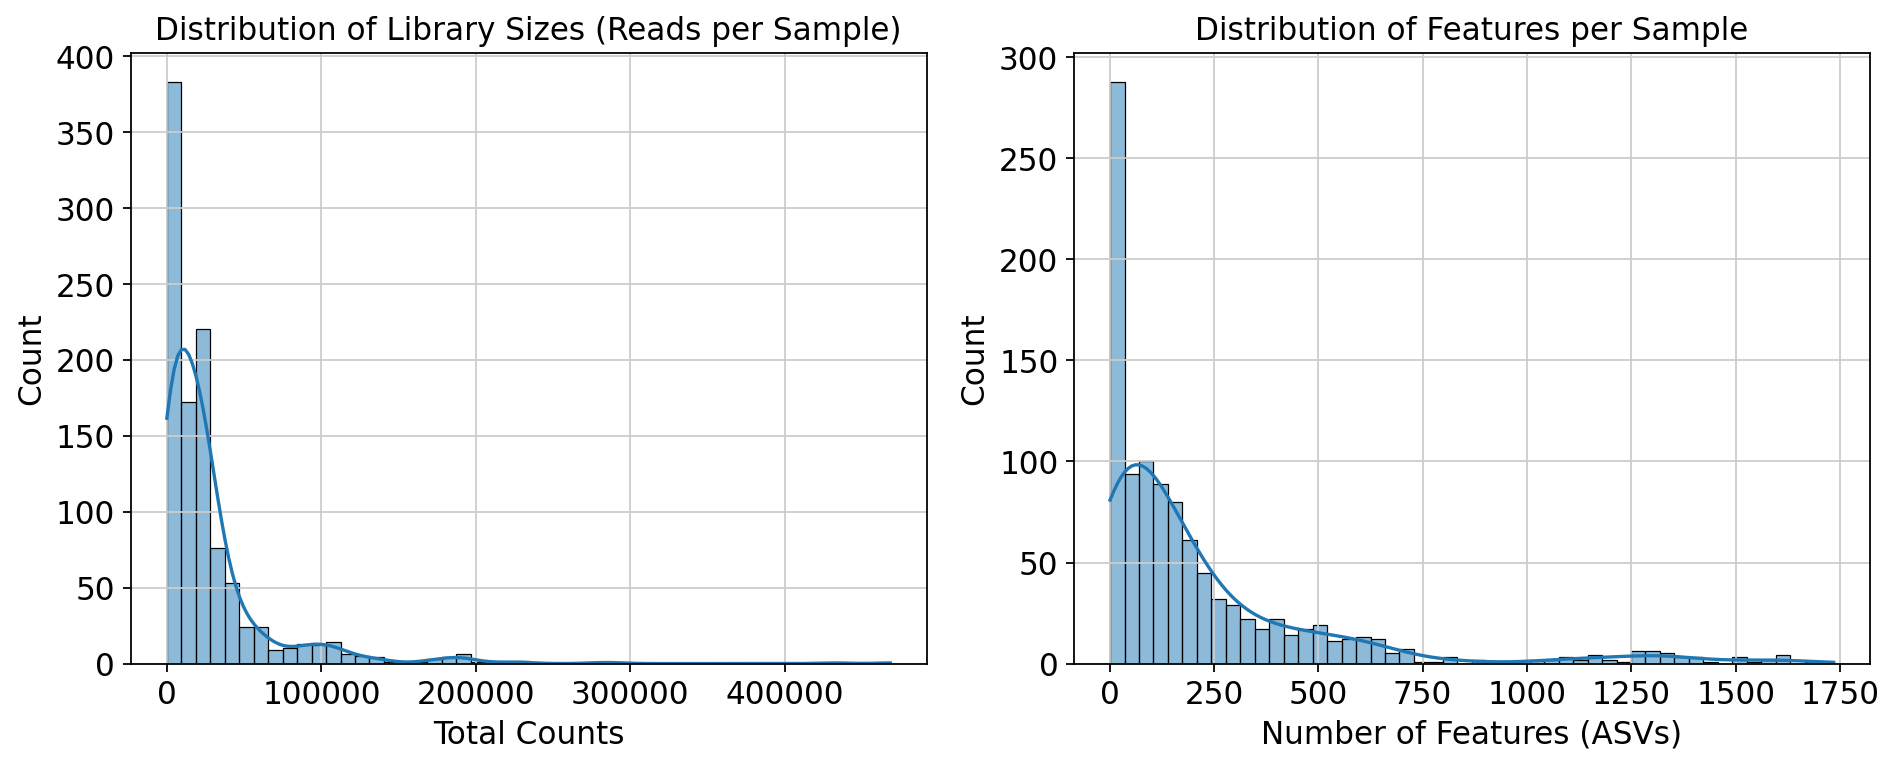

In [7]:
print("\n--- Step 3.4: Calculating and Visualizing QC Metrics ---")
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Plot QC metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=adata.obs, x='total_counts', ax=axes[0], bins=50, kde=True)
axes[0].set_title('Distribution of Library Sizes (Reads per Sample)')
axes[0].set_xlabel('Total Counts')

sns.histplot(data=adata.obs, x='n_genes_by_counts', ax=axes[1], bins=50, kde=True)
axes[1].set_title('Distribution of Features per Sample')
axes[1].set_xlabel('Number of Features (ASVs)')
plt.tight_layout()
plt.show()

In [8]:
print("\n--- Step 3.5: Filtering Low-Depth Samples and Low-Prevalence Features ---")

min_sequencing_depth = 5000
min_sample_prevalence = 2 # Feature must be in at least 2 samples

print(f"Samples before ANY filtering: {adata.n_obs}")
print(f"Features before ANY filtering: {adata.n_vars}")

# 1. Filter low-depth samples FIRST
sc.pp.filter_cells(adata, min_counts=min_sequencing_depth)
print(f"Samples after depth filtering: {adata.n_obs}")

# 2. Filter low-prevalence features SECOND
sc.pp.filter_genes(adata, min_cells=min_sample_prevalence)
print(f"Features after prevalence filtering: {adata.n_vars}")

# --- FIX: ADD THIS STEP ---
# 3. Filter any samples that are NOW empty after gene filtering
print(f"Filtering {np.sum(adata.X.sum(axis=1) == 0)} newly-empty samples...")
sc.pp.filter_cells(adata, min_counts=1)
print(f"Samples after final 'empty' filtering: {adata.n_obs}")
# --- END FIX ---

# 4. Store the final, clean counts in a layer
adata.layers['raw_counts'] = adata.X.copy()
print("\nStored filtered counts in adata.layers['raw_counts']")


--- Step 3.5: Filtering Low-Depth Samples and Low-Prevalence Features ---
Samples before ANY filtering: 1048
Features before ANY filtering: 155512
filtered out 283 cells that have less than 5000 counts
Samples after depth filtering: 765
filtered out 133913 genes that are detected in less than 2 cells
Features after prevalence filtering: 21599
Filtering 108 newly-empty samples...
filtered out 108 cells that have less than 1 counts
Samples after final 'empty' filtering: 657

Stored filtered counts in adata.layers['raw_counts']


## Part 4: Generate Phylogenetic Tree (External Steps)

This part requires external command-line tools (MAFFT and FastTree). We will first export the sequences, then provide the commands to run in your terminal. Finally, we'll load the resulting tree back into the AnnData object.

In [9]:
print("--- Step 4.1: Exporting FASTA for Tree Building ---")
# Drop any features that might not have a sequence after all filtering
sequences_df = adata.var.dropna(subset=['sequence'])

fasta_path = OUTPUT_DIR / "all_features.fasta"

print(f"Sanitizing {len(sequences_df)} feature IDs and writing to {fasta_path}...")
with open(fasta_path, "w") as f:
    for feature_id, seq in sequences_df['sequence'].items():
        # Sanitize the feature ID to remove any characters
        # that could corrupt the Newick format.
        sanitized_id = re.sub(r'[^a-zA-Z0-9_]', '_', str(feature_id))
        
        if isinstance(seq, str) and seq:
            f.write(f">{sanitized_id}\n")
            f.write(f"{seq}\n")

print(f"FASTA file written successfully.")

--- Step 4.1: Exporting FASTA for Tree Building ---
Sanitizing 21599 feature IDs and writing to anndata_pipeline_output/all_features.fasta...
FASTA file written successfully.


### --- Step 4.2: Run MAFFT and FastTree (In Terminal) ---

Please run the following commands in your terminal, in the same directory as this notebook. **This may take a long time.**

```bash
# 1. Align the sequences using MAFFT
mafft --auto anndata_pipeline_output/all_features.fasta > anndata_pipeline_output/all_features_aligned.fasta

# 2. Build the tree using FastTree
FastTree -nt anndata_pipeline_output/all_features_aligned.fasta > anndata_pipeline_output/final_newick_tree.nwk
```

In [10]:
print("--- Step 4.3: Importing Phylogenetic Tree ---")
newick_path = OUTPUT_DIR / "final_newick_tree.nwk"

if not newick_path.exists():
    print(f"❌ ERROR: The new tree file was not found at '{newick_path}'.")
    print("Please ensure you have completed Step 4.2 in your terminal before proceeding.")
else:
    # Read the tree string
    with open(newick_path, "r") as f:
        new_tree_str = f.read().strip()
    
    # Load into skbio.TreeNode and check tips
    try:
        tree = TreeNode.read(newick_path, format='newick')
        print(f"Successfully read tree with {len(list(tree.tips()))} tips.")
        
        # Important: Ensure tree tips match sanitized adata.var_names
        sanitized_var_names = [re.sub(r'[^a-zA-Z0-9_]', '_', str(name)) for name in adata.var_names]
        tree_tips = {tip.name for tip in tree.tips()}
        adata_vars = set(sanitized_var_names)
        
        missing_in_tree = list(adata_vars - tree_tips)
        if missing_in_tree:
            print(f"Warning: {len(missing_in_tree)} features are in AnnData but not in the tree.")
            print("This can happen due to filtering. Slicing AnnData object to match tree...")
            # Filter adata to only include features present in the tree
            sanitized_var_series = pd.Series(sanitized_var_names, index=adata.var_names)
            features_in_tree = sanitized_var_series[sanitized_var_series.isin(tree_tips)].index
            adata = adata[:, features_in_tree].copy()
            adata.layers['raw_counts'] = adata.layers['raw_counts'][:, features_in_tree].copy()
            print(f"New adata shape after tree filtering: {adata.shape}")

        # Update the .uns dictionary with the tree string
        adata.uns['phylogenetic_tree'] = new_tree_str
        print("✅ Successfully updated adata.uns with the new phylogenetic tree.")
        
    except Exception as e:
        print(f"❌ ERROR: Failed to read or process the Newick file. Error: {e}")

--- Step 4.3: Importing Phylogenetic Tree ---
Successfully read tree with 18260 tips.
This can happen due to filtering. Slicing AnnData object to match tree...
❌ ERROR: Failed to read or process the Newick file. Error: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


## Part 5: Alpha Diversity (ASV Level)

We calculate alpha diversity on the raw, filtered counts.

--- Step 5.1: Calculating Alpha Diversity ---


/usr2/people/macgregor/miniconda3/envs/workflow_16s/lib/python3.10/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


Alpha diversity metrics added to adata.obs.
Skipping plot for 'batch': not suitable for boxplot (unique values: 21).
Skipping plot for 'environment_biome': not suitable for boxplot (unique values: 21).
Plotting alpha diversity by 'environment_material'...


/opt/tmp/ipykernel_2207264/1245295365.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


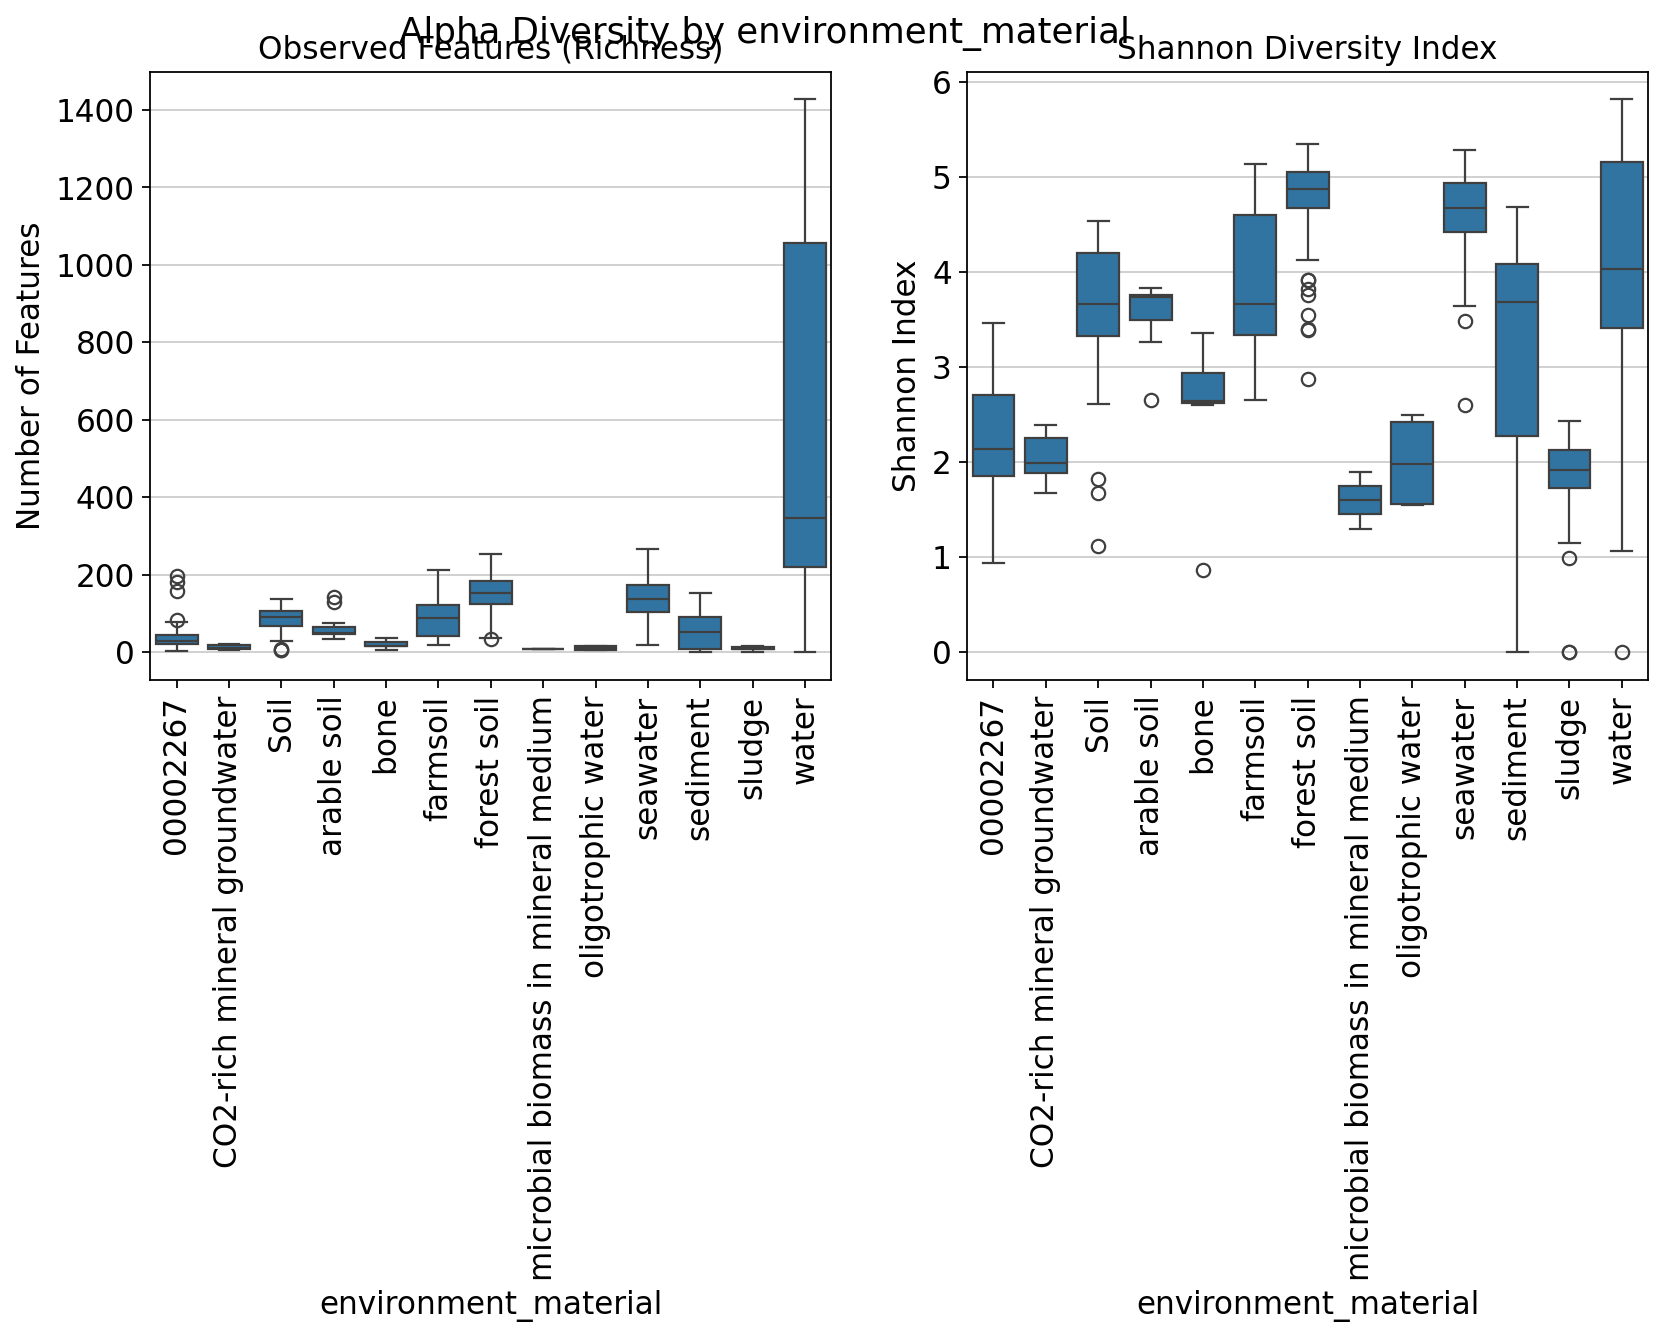

Skipping plot for 'environment_feature': not suitable for boxplot (unique values: 23).
Skipping plot for 'instrument_platform': not suitable for boxplot (unique values: 1).
Skipping plot for 'library_strategy': not suitable for boxplot (unique values: 1).
Skipping plot for 'country': not suitable for boxplot (unique values: 23).
Skipping plot for 'empo_1': not suitable for boxplot (unique values: 1).
Plotting alpha diversity by 'empo_2'...


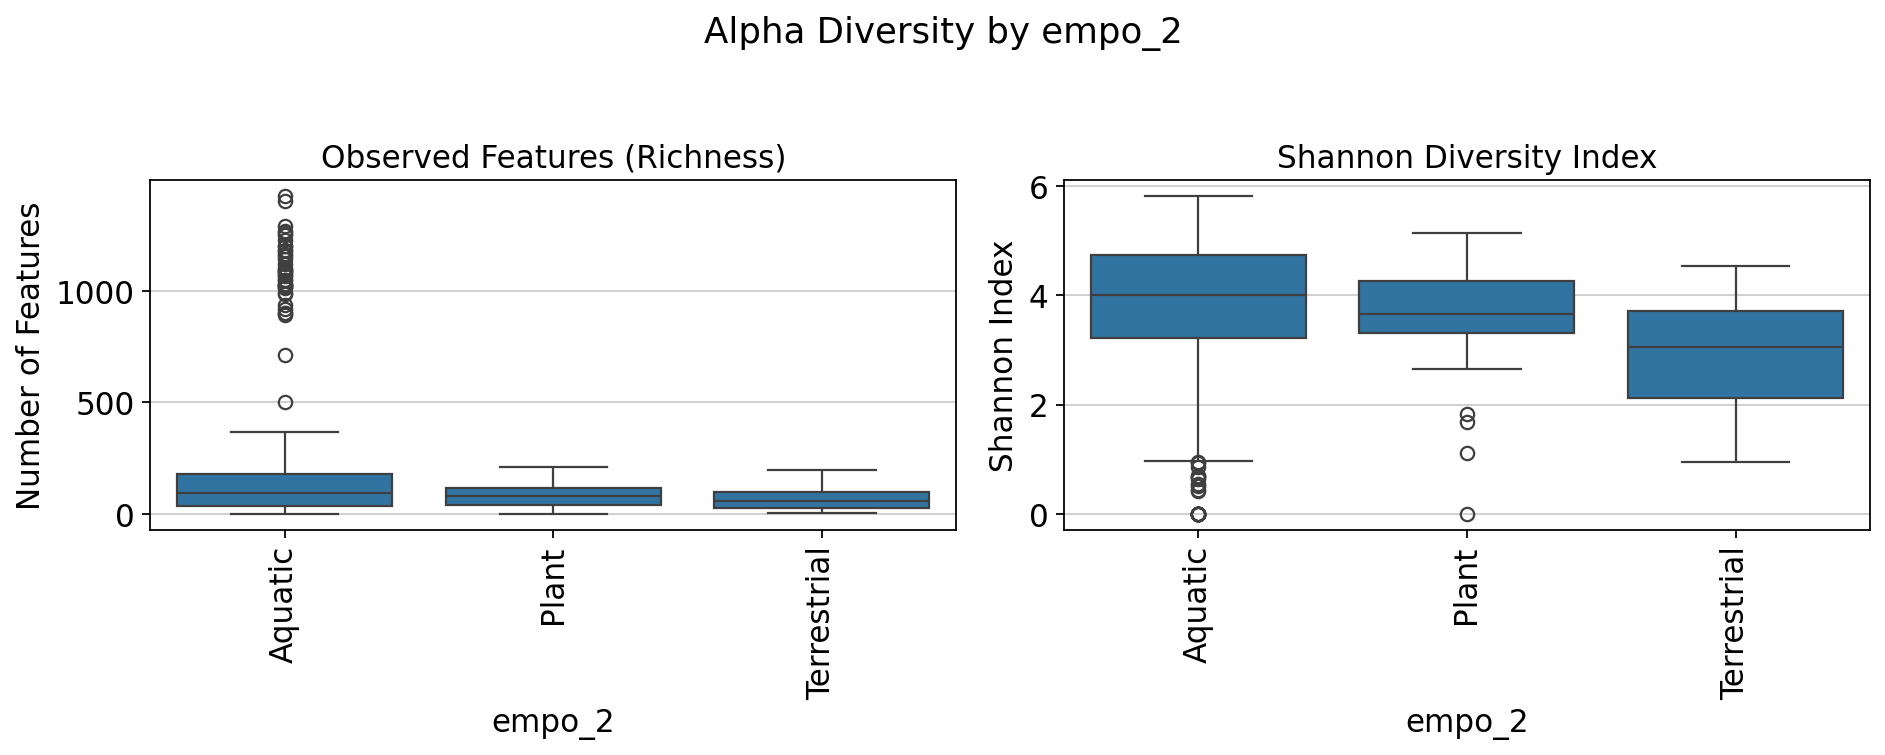

Plotting alpha diversity by 'empo_3'...


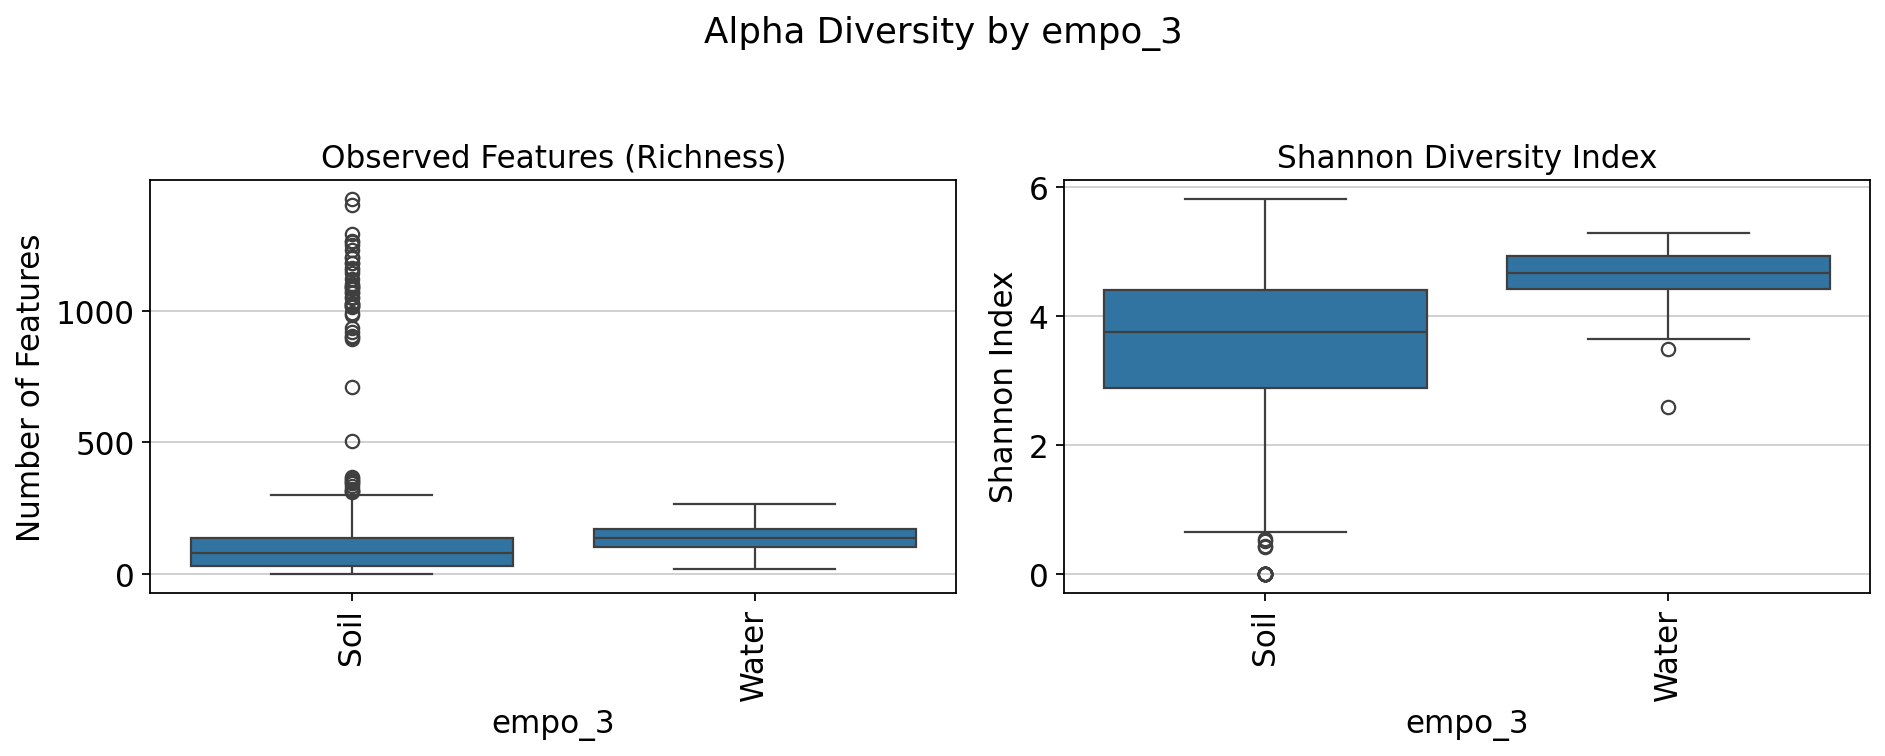

In [11]:
print("--- Step 5.1: Calculating Alpha Diversity ---")
# Get the raw counts matrix (samples x features)
counts_matrix = adata.layers['raw_counts'].toarray() if hasattr(adata.layers['raw_counts'], "toarray") else adata.layers['raw_counts']

# Calculate metrics and add them to our sample metadata (adata.obs)
adata.obs['observed_features'] = alpha_diversity('observed_otus', counts_matrix, ids=adata.obs_names).values
adata.obs['shannon_diversity'] = alpha_diversity('shannon', counts_matrix, ids=adata.obs_names).values

print("Alpha diversity metrics added to adata.obs.")

# --- Step 5.2: Visualizing Alpha Diversity ---
# Define columns of interest for plotting
group_columns = ['batch', 'environment_biome', 'environment_material', 'environment_feature', 
                 'instrument_platform', 'library_strategy', 'country', 'empo_1', 'empo_2', 'empo_3']

for group_column in group_columns:
    if group_column not in adata.obs.columns:
        print(f"Skipping plot for '{group_column}': column not found.")
        continue
    
    # Skip if the column has too many unique values or is mostly NaNs
    if adata.obs[group_column].nunique() > 20 or adata.obs[group_column].nunique() < 2:
        print(f"Skipping plot for '{group_column}': not suitable for boxplot (unique values: {adata.obs[group_column].nunique()}).")
        continue

    print(f"Plotting alpha diversity by '{group_column}'...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Alpha Diversity by {group_column}", fontsize=16)
    
    sns.boxplot(data=adata.obs, x=group_column, y='observed_features', ax=ax1)
    ax1.set_title('Observed Features (Richness)')
    ax1.set_ylabel('Number of Features')
    ax1.set_xlabel(group_column)
    ax1.tick_params(axis='x', rotation=90)

    sns.boxplot(data=adata.obs, x=group_column, y='shannon_diversity', ax=ax2)
    ax2.set_title('Shannon Diversity Index')
    ax2.set_ylabel('Shannon Index')
    ax2.set_xlabel(group_column)
    ax2.tick_params(axis='x', rotation=90)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Part 6: Beta Diversity (ASV Level)

- **Bray-Curtis** (non-phylogenetic) is calculated on **normalized** data.
- **UniFrac** (phylogenetic) is calculated on **raw** count data.

In [ ]:
print("--- Step 6.1: Calculating Beta Diversity ---")

# --- 1. Bray-Curtis (Normalized) ---
print("Calculating Bray-Curtis...")
# Create a temporary normalized object for BC calculation
adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum=1)
norm_counts = adata_norm.X.toarray() if hasattr(adata_norm.X, "toarray") else adata_norm.X
bc_dm = beta_diversity('braycurtis', norm_counts, ids=adata_norm.obs_names)
bc_pcoa = pcoa(bc_dm)
adata.obsm['X_bc_pcoa'] = bc_pcoa.samples
adata.uns['bc_pcoa_variance_explained'] = bc_pcoa.proportion_explained

# --- 2. Phylogenetic (Raw Counts) ---
if 'phylogenetic_tree' in adata.uns:
    print("Calculating Weighted UniFrac...")
    # Get raw counts and sanitized var names again
    raw_counts = adata.layers['raw_counts'].toarray() if hasattr(adata.layers['raw_counts'], "toarray") else adata.layers['raw_counts']
    sanitized_var_names = [re.sub(r'[^a-zA-Z0-9_]', '_', str(name)) for name in adata.var_names]
    tree = TreeNode.read([adata.uns['phylogenetic_tree']], format='newick')
    
    # --- NEW FIX: Root the tree at its midpoint ---
    print("Rooting the tree at its midpoint...")
    tree = tree.root_at_midpoint()
    # --- END NEW FIX ---

    # --- FIX: Renamed 'otu_ids' to 'taxa' ---
    wu_dm = beta_diversity('weighted_unifrac', raw_counts, ids=adata.obs_names, taxa=sanitized_var_names, tree=tree)
    wu_pcoa = pcoa(wu_dm)
    adata.obsm['X_wu_pcoa'] = wu_pcoa.samples
    adata.uns['wu_pcoa_variance_explained'] = wu_pcoa.proportion_explained

    print("Calculating Unweighted UniFrac...")
    # --- FIX: Renamed 'otu_ids' to 'taxa' ---
    uu_dm = beta_diversity('unweighted_unifrac', raw_counts, ids=adata.obs_names, taxa=sanitized_var_names, tree=tree)
    uu_pcoa = pcoa(uu_dm)
    adata.obsm['X_uu_pcoa'] = uu_pcoa.samples
    adata.uns['uu_pcoa_variance_explained'] = uu_pcoa.proportion_explained
    
    print("✅ All diversity metrics calculated.")
else:
    print("Skipping phylogenetic diversity: Tree not found in adata.uns.")

In [ ]:
print("--- Step 6.2: Visualizing Beta Diversity (PCoA) ---")

plot_columns = ['batch', 'environment_biome', 'environment_feature', 'environment_material', 'empo_1', 'empo_2', 'empo_3', 'facility_match']
plot_metrics = [('Bray-Curtis', 'X_bc_pcoa', 'bc_pcoa_variance_explained'), 
                ('Weighted UniFrac', 'X_wu_pcoa', 'wu_pcoa_variance_explained'),
                ('Unweighted UniFrac', 'X_uu_pcoa', 'uu_pcoa_variance_explained')]

for title, obsm_key, uns_key in plot_metrics:
    if obsm_key not in adata.obsm:
        print(f"Skipping {title} plot: Data not found in adata.obsm.")
        continue
    
    pc_expl = adata.uns[uns_key]
    
    for group_column in plot_columns:
        if group_column not in adata.obs.columns or adata.obs[group_column].nunique() < 2:
            continue
            
        print(f"Plotting {title} PCoA colored by {group_column}...")
        plt.figure(figsize=(10, 12))
        sns.scatterplot(x=adata.obsm[obsm_key]['PC1'], 
                        y=adata.obsm[obsm_key]['PC2'], 
                        hue=adata.obs[group_column], 
                        s=50)
        plt.title(f"{title} PCoA by {group_column}")
        plt.xlabel(f"PC1 ({pc_expl[0]:.2%})")
        plt.ylabel(f"PC2 ({pc_expl[1]:.2%})")
        plt.legend(title=group_column, loc='center left', bbox_to_anchor=(1.05, 0.5))
        plt.tight_layout()
        plt.show()


In [ ]:
# --- This is a new cell to be inserted before Part 6.3 ---

# 1. Automatically identify columns for plotting (Goal 3)
categorical_cols = []
numerical_cols = []

print("Identifying columns for plotting...")
for col in adata.obs.columns:
    col_dtype = adata.obs[col].dtype
    
    # Check for categorical or boolean types
    if col_dtype == 'object' or pd.api.types.is_categorical_dtype(col_dtype) or pd.api.types.is_bool_dtype(col_dtype):
        # Avoid plotting high-cardinality columns
        if adata.obs[col].nunique() < 50: 
            categorical_cols.append(col)
            
    # Check for numeric types
    elif pd.api.types.is_numeric_dtype(col_dtype):
        # Avoid plotting columns with only one value
        if adata.obs[col].nunique() > 1:
             numerical_cols.append(col)

print(f"Found {len(categorical_cols)} categorical columns: {categorical_cols}")
print(f"Found {len(numerical_cols)} numerical columns: {numerical_cols}")

# 2. Add specific taxonomic abundances to plot (Goal 2)
# Define the phyla (or other taxa) you want to see
taxa_to_plot = ['Bacteroidota', 'Firmicutes', 'Proteobacteria', 'Actinobacteriota']

for taxon in taxa_to_plot:
    # Assuming 'Phylum' is the column name in adata.var from Part 3.1
    if taxon in adata.var['Phylum'].values:
        print(f"Calculating abundance for {taxon}...")
        # Find all ASVs matching this taxon
        taxon_asvs = adata.var_names[adata.var['Phylum'] == taxon]
        
        # Sum their counts for each sample
        taxon_abundance = adata[:, taxon_asvs].X.sum(axis=1)
        
        # Add to adata.obs and also to our list of numerical columns to plot
        col_name = f'{taxon}_abundance'
        adata.obs[col_name] = np.array(taxon_abundance).flatten()
        if col_name not in numerical_cols:
            numerical_cols.append(col_name)
    else:
        print(f"Warning: Taxon '{taxon}' not found in adata.var['Phylum'].")
        
# This is the final list of columns to plot
all_color_columns = categorical_cols + numerical_cols
print(f"\nFinal list of {len(all_color_columns)} columns to plot: {all_color_columns}")

In [ ]:
# --- This is the modified Cell [18] (Part 6.3) ---

# Get the PCoA coordinates and join with metadata
pcoa_df = pd.DataFrame(adata.obsm['X_pcoa_braycurtis'][:, :2], 
                       columns=['PC1', 'PC2'], 
                       index=adata.obs_names)
pcoa_df = pcoa_df.join(adata.obs)

# Get variance explained for labels
var_exp = adata.uns['pcoa_braycurtis_variance']

# === MODIFICATION ===
# Use the comprehensive list created in the previous cell
# This list now contains auto-detected columns and the taxon abundances you added.
color_columns = all_color_columns 
# ====================

print(f"--- Plotting ASV-level PCoA for {len(color_columns)} metadata columns ---")

# Loop through all columns to color by
for col in color_columns:
    plt.figure(figsize=(7, 6))
    
    # Check if the column is categorical or numerical for plotting
    if pd.api.types.is_numeric_dtype(pcoa_df[col]):
        # --- Plot for numerical data (like abundances) ---
        ax = sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue=col, s=50, palette="viridis")
        # Get the colorbar legend
        norm = plt.Normalize(pcoa_df[col].min(), pcoa_df[col].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])
        # Remove the old legend
        ax.get_legend().remove()
        # Add a colorbar
        ax.figure.colorbar(sm, label=col, ax=ax, shrink=0.8)
    
    else:
        # --- Plot for categorical data (like 'batch') ---
        ax = sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue=col, s=50)
        # Move legend
        ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title=col)

    ax.set_title(f"Bray-Curtis PCoA (ASV Level) colored by {col}")
    ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
    ax.set_ylabel(f'PC2 ({var_exp[1]:.2%})')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

print("\n--- Finished plotting all ASV-level PCoAs ---")

## Part 7: Taxonomic Composition (Genus Level)

In [12]:
print("--- Step 7.1: Aggregating ASV counts to Genus level ---")
if 'Genus' not in adata.var.columns:
    print("Cannot aggregate to Genus: 'Genus' column not found.")
else:
    # Create a mapping from each ASV to its genus
    asv_to_genus = adata.var['Genus'].fillna('g__unassigned')
    unique_genera = asv_to_genus.unique()

    # Create a new data matrix for the genus-level counts (using raw counts)
    raw_counts_matrix = adata.layers['raw_counts'].toarray() if hasattr(adata.layers['raw_counts'], "toarray") else adata.layers['raw_counts']
    genus_X_df = pd.DataFrame(0, index=adata.obs_names, columns=unique_genera, dtype=np.float32)

    # Loop through each genus and sum the counts of its constituent ASVs
    for genus in unique_genera:
        asvs_in_genus_mask = (asv_to_genus == genus).values
        if np.any(asvs_in_genus_mask):
            genus_X_df[genus] = raw_counts_matrix[:, asvs_in_genus_mask].sum(axis=1)

    # Create a new AnnData object for the genus-level analysis
    adata_genus = ad.AnnData(X=genus_X_df.values, obs=adata.obs)
    adata_genus.var_names = unique_genera

    print(f"Created new 'adata_genus' object with shape: {adata_genus.shape}")

--- Step 7.1: Aggregating ASV counts to Genus level ---
Created new 'adata_genus' object with shape: (657, 1095)


In [20]:
def aggregate_adata_by_taxonomy(adata_in, tax_level='Genus'):
    """
    Aggregates an AnnData object by a specified taxonomic level.
    Assumes 'Taxon' and parsed levels (e.g., 'Genus') are in .var
    """
    print(f"--- Aggregating AnnData by {tax_level} ---")
    
    # Ensure input data is not modified
    adata_agg = adata_in.copy()
    
    # Check if the taxonomic level column exists
    if tax_level not in adata_agg.var.columns:
        print(f"Error: Taxonomic level '{tax_level}' not found in .var. Did you run Part 3.1?")
        return None
    
    # Replace NaN or <NA> with a placeholder
    adata_agg.var[tax_level] = adata_agg.var[tax_level].fillna('Unassigned')
    
    # --- 1. Group features by the taxonomic level ---
    asv_to_tax_map = adata_agg.var[tax_level]
    
    # --- 2. Create the aggregated count matrix (X) ---
    # Handle both sparse and dense data
    if 'scipy.sparse' in str(type(adata_agg.X)):
        counts_data = adata_agg.X.T.toarray()
    else:
        counts_data = adata_agg.X.T

    # Create a DataFrame from the (now dense) matrix X
    counts_df = pd.DataFrame(counts_data, 
                               index=adata_agg.var_names, 
                               columns=adata_agg.obs_names)
    
    # Group by the taxonomic map and sum the counts
    aggregated_counts_df = counts_df.groupby(asv_to_tax_map).sum()
    
    # --- 3. Create the new AnnData object ---
    # Transpose back so samples are observations (rows)
    adata_new = ad.AnnData(aggregated_counts_df.T)
    
    # === START OF FIX: Copy .obs metadata ===
    # This copies 'batch' and all other metadata to the new object
    adata_new.obs = adata_agg.obs.copy()
    # === END OF FIX ===
    
    # --- 4. Reconstruct .var metadata (optional) ---
    tax_levels = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    if tax_level in tax_levels:
        levels_to_keep = tax_levels[:tax_levels.index(tax_level) + 1]
    else:
        levels_to_keep = [tax_level]
    
    try:
        var_meta = adata_agg.var[levels_to_keep].drop_duplicates(subset=[tax_level])
        var_meta = var_meta.set_index(tax_level)
        adata_new.var = var_meta.reindex(adata_new.var_names)
    except Exception as e:
        print(f"Warning: Could not reconstruct .var metadata. Error: {e}")
    
    print(f"Aggregation complete. New shape: {adata_new.shape}")
    return adata_new

In [23]:
# --- This is the corrected cell for looping over all tax levels ---

import os # <-- FIX 1: Import os to create directories

# --- Define and create the output directory ---
output_dir = "./anndata_pipeline_output"
os.makedirs(output_dir, exist_ok=True) # This creates the folder if it's missing
print(f"Saving plots to: {output_dir}")
# ---

all_tax_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus'] 
print(f"--- Starting PCoA analysis for all taxonomic levels: {all_tax_levels} ---")

pcoa_results = {}
aggregated_adatas = {}
total_plots_saved = 0

for tax_level in all_tax_levels:
    print(f"\nProcessing taxonomic level: {tax_level}")
    
    # 1. Aggregate (using the updated function from Cell 14)
    adata_agg = aggregate_adata_by_taxonomy(adata, tax_level=tax_level)
    
    if adata_agg is None:
        print(f"Skipping {tax_level} due to aggregation error.")
        continue

    # 2. Filter Zero-Sum Samples
    if 'scipy.sparse' in str(type(adata_agg.X)):
        sample_sums = adata_agg.X.sum(axis=1).A1
    else:
        sample_sums = adata_agg.X.sum(axis=1)
    zero_count_samples = sample_sums == 0
    if np.any(zero_count_samples):
        n_zero = np.sum(zero_count_samples)
        print(f"Warning: Found {n_zero} samples with zero counts at {tax_level} level. Filtering them out.")
        adata_agg = adata_agg[~zero_count_samples, :].copy()
        if adata_agg.n_obs < 2: 
            print(f"Error: Not enough samples remaining after filtering for {tax_level}. Skipping.")
            continue
    
    # 3. Run Beta Diversity pipeline
    sc.pp.normalize_total(adata_agg, target_sum=1e4)
    sc.pp.log1p(adata_agg)

    if 'scipy.sparse' in str(type(adata_agg.X)):
        counts_for_beta = adata_agg.X.toarray()
    else:
        counts_for_beta = adata_agg.X

    bc_dist = beta_diversity("braycurtis", counts_for_beta, adata_agg.obs_names)
    bc_pcoa = pcoa(bc_dist)

    adata_agg.obsm['X_pcoa_braycurtis'] = bc_pcoa.samples
    adata_agg.uns['pcoa_braycurtis_variance'] = bc_pcoa.proportion_explained
    
    pcoa_results[tax_level] = bc_pcoa
    aggregated_adatas[tax_level] = adata_agg

    # 4. Plot the PCoA for ALL metadata columns
    all_color_columns = []
    print(f"Identifying metadata columns for {tax_level} level plotting...")
    for col in adata_agg.obs.columns:
        n_unique = adata_agg.obs[col].nunique()
        if n_unique <= 1: 
            continue 
        if n_unique > 50 and not pd.api.types.is_numeric_dtype(adata_agg.obs[col].dtype):
            converted_test = pd.to_numeric(adata_agg.obs[col].astype(str).str.replace(',', '.'), errors='coerce')
            if converted_test.isnull().all():
                print(f"Skipping high-cardinality categorical column: {col}")
                continue
        all_color_columns.append(col)
    print(f"Found {len(all_color_columns)} columns to plot: {all_color_columns}")

    pcoa_data = adata_agg.obsm['X_pcoa_braycurtis'].iloc[:, :2].values
    pcoa_df = pd.DataFrame(pcoa_data, 
                           columns=['PC1', 'PC2'], 
                           index=adata_agg.obs_names)
                           
    pcoa_df = pcoa_df.join(adata_agg.obs)
    var_exp = adata_agg.uns['pcoa_braycurtis_variance']

    print(f"Plotting PCoA for {tax_level}...")
    
    for col in all_color_columns:
        plt.figure(figsize=(7, 6))
        
        col_data_original = pcoa_df[col]
        col_data_converted = pd.to_numeric(
            col_data_original.astype(str).str.replace(',', '.'), 
            errors='coerce'
        )
        
        if pd.api.types.is_numeric_dtype(col_data_converted.dtype) and not col_data_converted.isnull().all():
            ax = sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', 
                                 hue=col_data_converted, 
                                 s=50, palette="viridis")
            norm = plt.Normalize(col_data_converted.min(), col_data_converted.max())
            sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
            sm.set_array([])
            ax.get_legend().remove()
            ax.figure.colorbar(sm, label=col, ax=ax, shrink=0.8)
            ax.set_title(f"Bray-Curtis PCoA ({tax_level} Level) by {col} (Numeric)")
        
        else:
            ax = sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', 
                                 hue=col_data_original, 
                                 s=50)
            ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title=col)
            ax.set_title(f"Bray-Curtis PCoA ({tax_level} Level) by {col} (Categorical)")

        ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
        ax.set_ylabel(f'PC2 ({var_exp[1]:.2%})')
        
        # === START OF FIX 2: Sanitize filename ===
        # Replace spaces and invalid characters before saving
        safe_col_name = str(col).replace(' ', '_').replace('/', '_')
        safe_col_name = safe_col_name.replace('(', '').replace(')', '')
        safe_col_name = safe_col_name.replace(':', '').replace('.', '')
        # Truncate if the name is too long
        if len(safe_col_name) > 50:
             safe_col_name = safe_col_name[:50]
        
        # Use the output_dir variable and the new safe name
        fig_path = f"{output_dir}/pcoa_{tax_level}_level_{safe_col_name}.png"
        # === END OF FIX 2 ===
        
        plt.savefig(fig_path, bbox_inches='tight')
        plt.close() # Close plot to avoid flooding the notebook
        total_plots_saved += 1

print(f"\n--- Completed PCoA for all taxonomic levels. Saved {total_plots_saved} PNG files. ---")

Saving plots to: ./anndata_pipeline_output
--- Starting PCoA analysis for all taxonomic levels: ['Phylum', 'Class', 'Order', 'Family', 'Genus'] ---

Processing taxonomic level: Phylum
--- Aggregating AnnData by Phylum ---
Aggregation complete. New shape: (657, 77)
normalizing counts per cell
    finished (0:00:00)


/usr2/people/macgregor/miniconda3/envs/workflow_16s/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -2.2958263038121953 whereas the largest positive one is 59.785871037674404.
  warn(


Identifying metadata columns for Phylum level plotting...
Skipping high-cardinality categorical column: run_accession
Skipping high-cardinality categorical column: accession
Skipping high-cardinality categorical column: biosample_collection_date
Skipping high-cardinality categorical column: biosample_description
Skipping high-cardinality categorical column: biosample_external_id
Skipping high-cardinality categorical column: biosample_insdc_last_update
Skipping high-cardinality categorical column: biosample_insdc_secondary_accession
Skipping high-cardinality categorical column: biosample_lat_lon
Skipping high-cardinality categorical column: biosample_sample_name
Skipping high-cardinality categorical column: biosample_sra_accession
Skipping high-cardinality categorical column: biosample_title
Skipping high-cardinality categorical column: collection_date
Skipping high-cardinality categorical column: collection_date_end
Skipping high-cardinality categorical column: collection_date_start
Sk

/opt/tmp/ipykernel_2207264/3735757328.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328.py:113: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(f'PC2 ({var_exp[1]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328


Processing taxonomic level: Class
--- Aggregating AnnData by Class ---
Aggregation complete. New shape: (657, 183)
normalizing counts per cell
    finished (0:00:00)


...


Processing taxonomic level: Genus
--- Aggregating AnnData by Genus ---
Aggregation complete. New shape: (657, 1095)
normalizing counts per cell
    finished (0:00:00)


/usr2/people/macgregor/miniconda3/envs/workflow_16s/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.409038689402229 whereas the largest positive one is 39.677896952258465.
  warn(


Identifying metadata columns for Genus level plotting...
Skipping high-cardinality categorical column: run_accession
Skipping high-cardinality categorical column: accession
Skipping high-cardinality categorical column: biosample_collection_date
Skipping high-cardinality categorical column: biosample_description
Skipping high-cardinality categorical column: biosample_external_id
Skipping high-cardinality categorical column: biosample_insdc_last_update
Skipping high-cardinality categorical column: biosample_insdc_secondary_accession
Skipping high-cardinality categorical column: biosample_lat_lon
Skipping high-cardinality categorical column: biosample_sample_name
Skipping high-cardinality categorical column: biosample_sra_accession
Skipping high-cardinality categorical column: biosample_title
Skipping high-cardinality categorical column: collection_date
Skipping high-cardinality categorical column: collection_date_end
Skipping high-cardinality categorical column: collection_date_start
Ski

/opt/tmp/ipykernel_2207264/3735757328.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328.py:113: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(f'PC2 ({var_exp[1]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f'PC1 ({var_exp[0]:.2%})')
/opt/tmp/ipykernel_2207264/3735757328


--- Completed PCoA for all taxonomic levels. Saved 1365 PNG files. ---


In [25]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import re
import os

# --- Ensure output directory exists (defined in previous cell) ---
output_dir = "./anndata_pipeline_output"
os.makedirs(output_dir, exist_ok=True) 

all_results_dfs = []
total_plots_saved = 0

print(f"--- 🔬 Starting Statistical Association Analysis ---")
print(f"Output will be saved to: {output_dir}")

# Loop over each aggregated AnnData object from the previous step
if 'aggregated_adatas' not in locals():
    print("Error: 'aggregated_adatas' dictionary not found. Please run the previous cell first.")
else:
    for tax_level, adata_agg in aggregated_adatas.items():
        print(f"\n{'='*20}\nAnalyzing Level: {tax_level}\n{'='*20}")
        
        if adata_agg.n_obs < 3:
            print(f"Skipping {tax_level}, not enough samples (n={adata_agg.n_obs}).")
            continue

        level_results = []
        
        # --- 1. Identify Taxa to Test (Top 20 most abundant) ---
        if 'scipy.sparse' in str(type(adata_agg.X)):
            mean_abund = adata_agg.X.mean(axis=0).A1
        else:
            mean_abund = adata_agg.X.mean(axis=0)
        
        abund_df = pd.DataFrame({'taxon': adata_agg.var_names, 'mean_abund': mean_abund})
        abund_df = abund_df.sort_values(by='mean_abund', ascending=False)
        taxa_to_test = abund_df.head(20)['taxon'].tolist()
        
        print(f"Testing top {len(taxa_to_test)} most abundant taxa (out of {adata_agg.n_vars})...")
        
        # --- 2. Identify Metadata to Test (from robust check) ---
        metadata_to_test = []
        for col in adata_agg.obs.columns:
            n_unique = adata_agg.obs[col].nunique()
            if n_unique <= 1: 
                continue # Skip columns with only one value

            if n_unique > 50 and not pd.api.types.is_numeric_dtype(adata_agg.obs[col].dtype):
                converted_test = pd.to_numeric(adata_agg.obs[col].astype(str).str.replace(',', '.'), errors='coerce')
                if converted_test.isnull().all():
                    continue # Skip high-cardinality categorical
            
            metadata_to_test.append(col)
        
        print(f"Testing against {len(metadata_to_test)} metadata columns...")

        # --- 3. Create a single DataFrame for testing ---
        if 'scipy.sparse' in str(type(adata_agg.X)):
            data_df = pd.DataFrame(adata_agg.X.toarray(), columns=adata_agg.var_names, index=adata_agg.obs_names)
        else:
            data_df = pd.DataFrame(adata_agg.X, columns=adata_agg.var_names, index=adata_agg.obs_names)
        
        data_df = data_df.join(adata_agg.obs)

        # --- 4. Run Statistical Tests ---
        for taxon in taxa_to_test:
            taxon_abundance = data_df[taxon]
            
            for col in metadata_to_test:
                metadata_values = data_df[col]
                
                # Robust numeric conversion
                col_data_converted = pd.to_numeric(
                    metadata_values.astype(str).str.replace(',', '.'), 
                    errors='coerce'
                )
                is_numeric = pd.api.types.is_numeric_dtype(col_data_converted.dtype) and not col_data_converted.isnull().all()
                
                # Combine and drop NaNs for this specific test
                test_df = pd.DataFrame({'taxon': taxon_abundance, 'meta': col_data_converted if is_numeric else metadata_values}).dropna()
                
                if test_df.shape[0] < 3: # Not enough data to test
                    continue
                
                try:
                    if is_numeric:
                        # --- Spearman Correlation ---
                        corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
                        level_results.append({
                            'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                            'test_type': 'Spearman', 'statistic': corr, 'p_value': p_val
                        })
                    else:
                        # --- Categorical Tests ---
                        groups = test_df['meta'].unique()
                        n_groups = len(groups)
                        
                        if n_groups == 2:
                            # --- Mann-Whitney U ---
                            g1 = test_df[test_df['meta'] == groups[0]]['taxon']
                            g2 = test_df[test_df['meta'] == groups[1]]['taxon']
                            if g1.shape[0] < 1 or g2.shape[0] < 1: continue
                            stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                            level_results.append({
                                'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                                'test_type': 'Mann-Whitney U', 'statistic': stat, 'p_value': p_val
                            })
                        elif n_groups > 2:
                            # --- Kruskal-Wallis ---
                            group_data = [test_df[test_df['meta'] == g]['taxon'] for g in groups if test_df[test_df['meta'] == g]['taxon'].shape[0] > 0]
                            if len(group_data) < 2: continue
                            stat, p_val = stats.kruskal(*group_data)
                            level_results.append({
                                'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                                'test_type': 'Kruskal-Wallis', 'statistic': stat, 'p_value': p_val
                            })
                except Exception as e:
                    print(f"Warning: Test failed for {taxon} vs {col}. Error: {e}")

        # --- 5. FDR Correction & Results Saving ---
        if not level_results:
            print(f"No valid statistical tests were run for {tax_level}.")
            continue
            
        results_df = pd.DataFrame(level_results).dropna(subset=['p_value'])
        
        if results_df.empty:
            print(f"No valid statistical results for {tax_level}.")
            continue
            
        results_df['p_adj'] = multipletests(results_df['p_value'], method='fdr_bh')[1]
        results_df = results_df.sort_values(by='p_adj')
        all_results_dfs.append(results_df)

        # --- 6. Print Summary and Save Results ---
        print(f"\n--- Top Associations for {tax_level} (p_adj < 0.05) ---")
        significant_results = results_df[results_df['p_adj'] < 0.05]
        
        if significant_results.empty:
            print("No significant associations found.")
        else:
            print(significant_results.head(10).to_string())

        level_csv_path = f"{output_dir}/stats_associations_{tax_level}.csv"
        results_df.to_csv(level_csv_path, index=False)
        print(f"Saved all {results_df.shape[0]} test results to {level_csv_path}")

        # --- 7. Visualize Top 5 Significant Results ---
        print(f"Visualizing top {min(5, significant_results.shape[0])} significant results...")
        for _, row in significant_results.head(5).iterrows():
            plt.figure(figsize=(6, 5))
            
            col = row['metadata_col']
            taxon = row['taxon']
            
            col_data_converted = pd.to_numeric(data_df[col].astype(str).str.replace(',', '.'), errors='coerce')
            is_numeric = pd.api.types.is_numeric_dtype(col_data_converted.dtype) and not col_data_converted.isnull().all()
            
            plot_df = pd.DataFrame({'meta': col_data_converted if is_numeric else data_df[col], 'taxon': data_df[taxon]})
            
            if row['test_type'] == 'Spearman':
                ax = sns.regplot(data=plot_df, x='meta', y='taxon', line_kws={'color':'red', 'linestyle':'--'})
                ax.set_xlabel(col)
                ax.set_title(f"{taxon} vs. {col}\nSpearman $rho$={row['statistic']:.2f}, $p_{{adj}}$={row['p_adj']:.2e}")
            else:
                ax = sns.boxplot(data=plot_df, x='meta', y='taxon', palette='vlag')
                sns.stripplot(data=plot_df, x='meta', y='taxon', color='0.25', alpha=0.5, dodge=True)
                ax.set_xlabel(col)
                ax.set_title(f"{taxon} by {col}\n{row['test_type']}, $p_{{adj}}$={row['p_adj']:.2e}")
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

            ax.set_ylabel(f"{taxon} Abundance")
            
            # Sanitize filename
            safe_col = re.sub(r'[^A-Za-z0-9_]+', '', col)[:30]
            safe_taxon = re.sub(r'[^A-Za-z0-9_]+', '', taxon)[:30]
            fig_path = f"{output_dir}/stat_plot_{tax_level}_{safe_taxon}_vs_{safe_col}.png"
            
            plt.savefig(fig_path, bbox_inches='tight')
            plt.close()
            total_plots_saved += 1
    
    # --- 8. Save a combined CSV of all results ---
    if all_results_dfs:
        final_results_df = pd.concat(all_results_dfs).sort_values(by='p_adj')
        final_csv_path = f"{output_dir}/stats_associations_ALL_LEVELS.csv"
        final_results_df.to_csv(final_csv_path, index=False)
        print(f"\n{'='*20}\n✅ Analysis Complete.\nSaved {total_plots_saved} plots.")
        print(f"Saved combined summary of all {final_results_df.shape[0]} tests to {final_csv_path}")
    else:
        print("\n--- Analysis Complete. No results were generated. ---")

--- 🔬 Starting Statistical Association Analysis ---
Output will be saved to: ./anndata_pipeline_output

Analyzing Level: Phylum
Testing top 20 most abundant taxa (out of 77)...
Testing against 273 metadata columns...


/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_

/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_

/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_

/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_

...

/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_

/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
/opt/tmp/ipykernel_2207264/3744824396.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(test_


--- Top Associations for Genus (p_adj < 0.05) ---
     tax_level           taxon                 metadata_col       test_type   statistic       p_value         p_adj
2414     Genus  Bradyrhizobium  biosample_insdc_center_name  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2422     Genus  Bradyrhizobium                  center_name  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2443     Genus  Bradyrhizobium    secondary_study_accession  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2445     Genus  Bradyrhizobium              study_accession  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2446     Genus  Bradyrhizobium                  study_alias  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2447     Genus  Bradyrhizobium                  study_title  Kruskal-Wallis  472.303465  2.309530e-90  1.800664e-87
2420     Genus  Bradyrhizobium       biosample_project_name  Kruskal-Wallis  472.303465  1.277321e-89  8.045631e-87
2423     Genus  Brady

/opt/tmp/ipykernel_2207264/3744824396.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=plot_df, x='meta', y='taxon', palette='vlag')
/opt/tmp/ipykernel_2207264/3744824396.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/opt/tmp/ipykernel_2207264/3744824396.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=plot_df, x='meta', y='taxon', palette='vlag')
/opt/tmp/ipykernel_2207264/3744824396.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a 


✅ Analysis Complete.
Saved 25 plots.
Saved combined summary of all 24677 tests to ./anndata_pipeline_output/stats_associations_ALL_LEVELS.csv


In [ ]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import re
import os

# --- Ensure output directory exists (defined in previous cell) ---
output_dir = "./anndata_pipeline_output"
os.makedirs(output_dir, exist_ok=True) 

all_results_dfs = []
total_plots_saved = 0

print(f"--- 🔬 Starting Statistical Association Analysis ---")
print(f"Output will be saved to: {output_dir}")

# Loop over each aggregated AnnData object from the previous step
if 'aggregated_adatas' not in locals():
    print("Error: 'aggregated_adatas' dictionary not found. Please run the previous cell first.")
else:
    for tax_level, adata_agg in aggregated_adatas.items():
        print(f"\n{'='*20}\nAnalyzing Level: {tax_level}\n{'='*20}")
        
        if adata_agg.n_obs < 3:
            print(f"Skipping {tax_level}, not enough samples (n={adata_agg.n_obs}).")
            continue

        level_results = []
        
        # --- 1. Identify Taxa to Test (Top 20 most abundant) ---
        if 'scipy.sparse' in str(type(adata_agg.X)):
            mean_abund = adata_agg.X.mean(axis=0).A1
        else:
            mean_abund = adata_agg.X.mean(axis=0)
        
        abund_df = pd.DataFrame({'taxon': adata_agg.var_names, 'mean_abund': mean_abund})
        abund_df = abund_df.sort_values(by='mean_abund', ascending=False)
        taxa_to_test = abund_df.head(200)['taxon'].tolist()
        
        print(f"Testing top {len(taxa_to_test)} most abundant taxa (out of {adata_agg.n_vars})...")
        
        # --- 2. Identify Metadata to Test (from robust check) ---
        metadata_to_test = []
        for col in adata_agg.obs.columns:
            n_unique = adata_agg.obs[col].nunique()
            if n_unique <= 1: 
                continue 

            if n_unique > 50 and not pd.api.types.is_numeric_dtype(adata_agg.obs[col].dtype):
                converted_test = pd.to_numeric(adata_agg.obs[col].astype(str).str.replace(',', '.'), errors='coerce')
                if converted_test.isnull().all():
                    continue 
            
            metadata_to_test.append(col)
        
        print(f"Testing against {len(metadata_to_test)} metadata columns...")

        # --- 3. Create a single DataFrame for testing ---
        if 'scipy.sparse' in str(type(adata_agg.X)):
            data_df = pd.DataFrame(adata_agg.X.toarray(), columns=adata_agg.var_names, index=adata_agg.obs_names)
        else:
            data_df = pd.DataFrame(adata_agg.X, columns=adata_agg.var_names, index=adata_agg.obs_names)
        
        data_df = data_df.join(adata_agg.obs)

        # --- 4. Run Statistical Tests ---
        for taxon in taxa_to_test:
            taxon_abundance = data_df[taxon]
            
            for col in metadata_to_test:
                metadata_values = data_df[col]
                
                col_data_converted = pd.to_numeric(
                    metadata_values.astype(str).str.replace(',', '.'), 
                    errors='coerce'
                )
                is_numeric = pd.api.types.is_numeric_dtype(col_data_converted.dtype) and not col_data_converted.isnull().all()
                
                test_df = pd.DataFrame({'taxon': taxon_abundance, 'meta': col_data_converted if is_numeric else metadata_values}).dropna()
                
                if test_df.shape[0] < 3: 
                    continue
                
                try:
                    if is_numeric:
                        corr, p_val = stats.spearmanr(test_df['taxon'], test_df['meta'])
                        level_results.append({
                            'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                            'test_type': 'Spearman', 'statistic': corr, 'p_value': p_val
                        })
                    else:
                        groups = test_df['meta'].unique()
                        n_groups = len(groups)
                        
                        if n_groups == 2:
                            g1 = test_df[test_df['meta'] == groups[0]]['taxon']
                            g2 = test_df[test_df['meta'] == groups[1]]['taxon']
                            if g1.shape[0] < 1 or g2.shape[0] < 1: continue
                            stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                            level_results.append({
                                'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                                'test_type': 'Mann-Whitney U', 'statistic': stat, 'p_value': p_val
                            })
                        elif n_groups > 2:
                            group_data = [test_df[test_df['meta'] == g]['taxon'] for g in groups if test_df[test_df['meta'] == g]['taxon'].shape[0] > 0]
                            if len(group_data) < 2: continue
                            stat, p_val = stats.kruskal(*group_data)
                            level_results.append({
                                'tax_level': tax_level, 'taxon': taxon, 'metadata_col': col, 
                                'test_type': 'Kruskal-WallIS', 'statistic': stat, 'p_value': p_val
                            })
                except Exception as e:
                    print(f"Warning: Test failed for {taxon} vs {col}. Error: {e}")

        # --- 5. FDR Correction & Results Saving ---
        if not level_results:
            print(f"No valid statistical tests were run for {tax_level}.")
            continue
            
        results_df = pd.DataFrame(level_results).dropna(subset=['p_value'])
        
        if results_df.empty:
            print(f"No valid statistical results for {tax_level}.")
            continue
            
        results_df['p_adj'] = multipletests(results_df['p_value'], method='fdr_bh')[1]
        results_df = results_df.sort_values(by='p_adj')
        all_results_dfs.append(results_df)

        # --- 6. Print Summary and Save Results ---
        print(f"\n--- Top Associations for {tax_level} (p_adj < 0.05) ---")
        significant_results = results_df[results_df['p_adj'] < 0.05]
        
        if significant_results.empty:
            print("No significant associations found.")
        else:
            print(significant_results.head(10).to_string())

        level_csv_path = f"{output_dir}/stats_associations_{tax_level}.csv"
        results_df.to_csv(level_csv_path, index=False)
        print(f"Saved all {results_df.shape[0]} test results to {level_csv_path}")

        # --- 7. Visualize Top Results ---
        # === CHANGE 1: Plot top 10 (was 5) ===
        print(f"Visualizing top {min(10, significant_results.shape[0])} significant results...")
        for _, row in significant_results.head(10).iterrows():
            plt.figure(figsize=(6, 5))
            
            col = row['metadata_col']
            taxon = row['taxon']
            
            col_data_converted = pd.to_numeric(data_df[col].astype(str).str.replace(',', '.'), errors='coerce')
            is_numeric = pd.api.types.is_numeric_dtype(col_data_converted.dtype) and not col_data_converted.isnull().all()
            
            plot_df = pd.DataFrame({'meta': col_data_converted if is_numeric else data_df[col], 'taxon': data_df[taxon]})
            
            if row['test_type'] == 'Spearman':
                ax = sns.regplot(data=plot_df, x='meta', y='taxon', line_kws={'color':'red', 'linestyle':'--'})
                ax.set_xlabel(col)
                ax.set_title(f"{taxon} vs. {col}\nSpearman $rho$={row['statistic']:.2f}, $p_{{adj}}$={row['p_adj']:.2e}")
            else:
                ax = sns.boxplot(data=plot_df, x='meta', y='taxon', palette='vlag')
                sns.stripplot(data=plot_df, x='meta', y='taxon', color='0.25', alpha=0.5, dodge=True)
                ax.set_xlabel(col)
                ax.set_title(f"{taxon} by {col}\n{row['test_type']}, $p_{{adj}}$={row['p_adj']:.2e}")
                
                # === CHANGE 2: Rotate 90 degrees (was 45) and center-align ===
                ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

            ax.set_ylabel(f"{taxon} Abundance")
            
            # Sanitize filename
            safe_col = re.sub(r'[^A-Za-z0-9_]+', '', col)[:30]
            safe_taxon = re.sub(r'[^A-Za-z0-9_]+', '', taxon)[:30]
            fig_path = f"{output_dir}/stat_plot_{tax_level}_{safe_taxon}_vs_{safe_col}.png"
            
            plt.savefig(fig_path, bbox_inches='tight')
            plt.close()
            total_plots_saved += 1
    
    # --- 8. Save a combined CSV of all results ---
    if all_results_dfs:
        final_results_df = pd.concat(all_results_dfs).sort_values(by='p_adj')
        final_csv_path = f"{output_dir}/stats_associations_ALL_LEVELS.csv"
        final_results_df.to_csv(final_csv_path, index=False)
        print(f"\n{'='*20}\n✅ Analysis Complete.\nSaved {total_plots_saved} plots.")
        print(f"Saved combined summary of all {final_results_df.shape[0]} tests to {final_csv_path}")
    else:
        print("\n--- Analysis Complete. No results were generated. ---")

In [ ]:
print("--- Step 7.2: Plotting Relative Abundance ---")
# Normalize to relative abundance (0-100)
sc.pp.normalize_total(adata_genus, target_sum=100)

# Get the top 15 most abundant genera
genus_means = np.array(adata_genus.X.mean(axis=0)).flatten()
top_15_indices = np.argsort(genus_means)[-15:]
top_genera = adata_genus.var_names[top_15_indices]

# Create a DataFrame for plotting
df_plot = pd.DataFrame(adata_genus[:, top_genera].X, index=adata_genus.obs_names, columns=top_genera)
df_plot['batch'] = adata_genus.obs['batch'].values

# Sort by a major genus for better visualization (e.g., the most abundant one)
df_plot = df_plot.sort_values(by=['batch', top_genera[-1]], ascending=[True, False])

# Plot
df_plot.drop(columns='batch').plot(kind='bar', stacked=True, figsize=(18, 7), width=1.0,
                                   cmap='tab20',
                                   title='Relative Abundance of Top 15 Genera')

plt.ylabel('Relative Abundance (%)')
plt.xlabel('Samples')
plt.xticks([]) # Hide sample names as they are too numerous
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

## Part 8: Save Final Results

In [ ]:
print("--- Step 8.1: Saving Processed AnnData Objects ---")

# --- Save the ASV-level object ---
try:
    # Convert 'Confidence' back to a compatible float type if it exists
    if 'Confidence' in adata.var.columns:
        adata.var['Confidence'] = adata.var['Confidence'].astype('float')
    
    # Resolve potential .obs index name conflict
    adata.obs.index.name = None

    final_adata_path = OUTPUT_DIR / "combined_analysis_ready.h5ad"
    adata.write_h5ad(final_adata_path)
    print(f"✅ Final ASV-level AnnData object saved to: {final_adata_path}")

except Exception as e:
    print(f"❌ Failed to save ASV-level object. Error: {e}")

# --- Save the Genus-level object ---
try:
    adata_genus.obs.index.name = None
    genus_adata_path = OUTPUT_DIR / "combined_genus_level.h5ad"
    adata_genus.write_h5ad(genus_adata_path)
    print(f"✅ Final Genus-level AnnData object saved to: {genus_adata_path}")
except Exception as e:
    print(f"❌ Failed to save Genus-level object. Error: {e}")